In [8]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [11]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *

In [110]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')

    # Preprocessing
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime'])
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=myLowColumns, inplace=True)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    # Remove temperature columns
    myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['Hypothermia', 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
    myXValue = myXValue
    myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myYValue, myPredictorsDf[aTreatmentColumn], stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [140]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                                                                                            aTreatmentColumn = 'treatment_hypothermia', aTreatmentSplit = True) 
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=10, n_estimators=20),  
    model_t= XGBClassifier(max_depth=10, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

Columns (14,16,41,51,63,65,66,76,80,89,99,111,113,114,124,128) have mixed types. Specify dtype option on import or set low_memory=False.


In [147]:
myColumns = pd.DataFrame(index=myDf[0].str.split('  ').str[0])
myColumns.drop('treatment_hypothermia', inplace=True)
X_train_no_group = X_train_no_group[myColumns.reset_index()[0]]
X_test_no_group = X_test_no_group[myColumns.reset_index()[0]]
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [142]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())


In [143]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.2s finished


0.11926103976206663


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.2s finished


Feature importances [0.00000000e+00 6.91091491e-01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.43507680e-05 0.00000000e+00
 0.00000000e+00 0.00000000e+00 7.64678725e-02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.34960855e-02 0.00000000e+00 3.84391548e-05
 2.56647368e-05 1.94113553e-03 1.96914961e-01]
Predicted CATE for test data: [[ 0.01839952]
 [ 0.08592192]
 [ 0.12371929]
 [ 0.12371929]
 [-0.08049301]
 [-0.0353181 ]
 [ 0.12371929]
 [ 0.12371929]
 [ 0.12371929]
 [-0.08049301]]


In [148]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  12 out of  25 | elapsed:    0.7s remaining:    0.8s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.7s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  25 out of  25 | elapsed:    0.7s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate              
===============================================================
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.024       0.043 0.551  0.582         -0.06         0.107
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.086           -0.08           0.124
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.096         -0.131          0.184
       Doubly Robust ATE on Training Data Results       
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE          0.015  0.019 0.803  0.422   -0.022    0.052
    Doubly Robust ATT(T=0) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT          0.025  0.031 0.798  0.425   -0.036    0.086
    Doubly Robust ATT(T=1) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT          0.007  0.023  0.29  0.772   -0.038    0.051
--------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

In [149]:
myNewXTest = myPipeline.transform(X_test_no_group)
causal_forest.score(y_test, T_test, myNewXTest)

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.2s


Optimization terminated successfully.
         Current function value: 0.424828
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.424637
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 0.7752310559446869
p-value: 0.378603632271325
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 2030
Model:                          Logit   Df Residuals:                     2027
Method:                           MLE   Df Model:                            2
Date:                Sun, 23 Feb 2025   Pseudo R-squ.:                 0.01181
Time:                        22:51:39   Log-Likelihood:                -862.40
converged:                       True   LL-Null:                       -872.71
Covariance Type:            nonrobust   LLR p-value:                 3.346e-05
                       

[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.2s finished


0.378603632271325

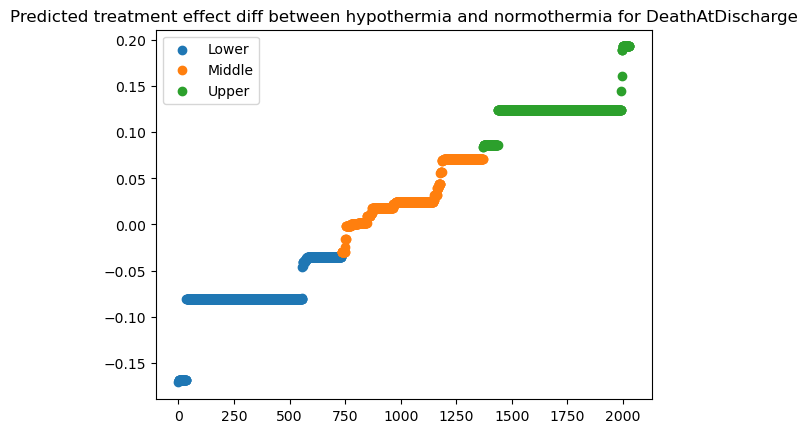

In [146]:
myNewXTest = myPipeline.transform(X_train_no_group)
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, 'DeathAtDischarge')

X_test_new = X_train_no_group.copy()
X_test_new['gender'] = T_train
y_train_df = pd.DataFrame()
y_train_df['DeathAtDischarge'] = y_train
getTreatmentEffectDiffDataFrame(X_test_new, y_train_df, myNewDf, 'DeathAtDischarge', 'gender', False)

In [62]:
myPredictorsDf.hypertension.sum()

219.0

In [106]:
myStuff = '''firstPTT ratio                                 15.2
maxFe/TIBC Ratio                             1257.0
minFe/TIBC Ratio                             1257.0
meanFe/TIBC Ratio                            1257.0
maxMotor                                     5272.0
Amikacin - trough                              34.5
firstPVRI                                    1000.0
lastPVRI                                     1000.0
GI obstruction / ileus                         12.0
general                                         7.0
hypokalemia                                    35.0
lower GI bleeding                              12.0
viscus perforation                             12.0
treatment_5-10 cm H2O                          49.0
treatment_fourth generation cephalosporin      31.0
treatment_glycoprotein IIB/IIIA inhibitor      23.0
treatment_hypothermia                         320.0
treatment_lidocaine                            12.0
treatment_sodium bicarbonate                   99.0
lastVerbal                                   2270.0'''
myStuff.split('\n')

['firstPTT ratio                                 15.2',
 'maxFe/TIBC Ratio                             1257.0',
 'minFe/TIBC Ratio                             1257.0',
 'meanFe/TIBC Ratio                            1257.0',
 'maxMotor                                     5272.0',
 'Amikacin - trough                              34.5',
 'firstPVRI                                    1000.0',
 'lastPVRI                                     1000.0',
 'GI obstruction / ileus                         12.0',
 'general                                         7.0',
 'hypokalemia                                    35.0',
 'lower GI bleeding                              12.0',
 'viscus perforation                             12.0',
 'treatment_5-10 cm H2O                          49.0',
 'treatment_fourth generation cephalosporin      31.0',
 'treatment_glycoprotein IIB/IIIA inhibitor      23.0',
 'treatment_hypothermia                         320.0',
 'treatment_lidocaine                           

In [107]:
myDf = pd.DataFrame(myStuff.split('\n'))

In [109]:
myDf[0].str.split('  ').str[0]

0                                firstPTT ratio
1                              maxFe/TIBC Ratio
2                              minFe/TIBC Ratio
3                             meanFe/TIBC Ratio
4                                      maxMotor
5                             Amikacin - trough
6                                     firstPVRI
7                                      lastPVRI
8                        GI obstruction / ileus
9                                       general
10                                  hypokalemia
11                            lower GI bleeding
12                           viscus perforation
13                        treatment_5-10 cm H2O
14    treatment_fourth generation cephalosporin
15    treatment_glycoprotein IIB/IIIA inhibitor
16                        treatment_hypothermia
17                          treatment_lidocaine
18                 treatment_sodium bicarbonate
19                                   lastVerbal
Name: 0, dtype: object